In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from _helper_functions import load_pickle_dict

import scipy.stats as stats

# This notebook can not be run
Since the result various between each bootstrap, this notebook can not be run to make the exact same figure.

In [5]:
rep2bin2p={}
rep2bin2z={}
for rep in [1,2,3]:

    bin2p=load_pickle_dict(f'F03-Syntax-Families-byreps/DICT-REP{rep}_Bin2RealPAdj.pydict.pickle')
    bin2z=load_pickle_dict(f'F03-Syntax-Families-byreps/DICT-REP{rep}_Bin2RealZ.pydict.pickle')


    rep2bin2p[rep]=bin2p
    rep2bin2z[rep]=bin2z

In [6]:
allbins=rep2bin2p[1].keys()

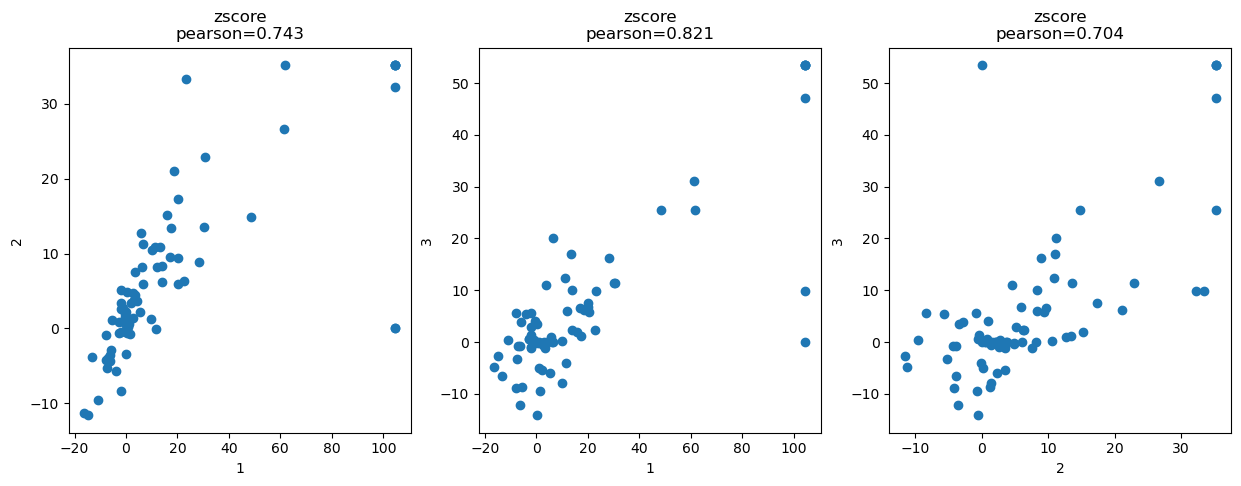

In [8]:

fig,ax=plt.subplots(1,3,figsize=(15,5))

d1s,d2s,d3s=[rep2bin2z[1][bi] if bi in rep2bin2z[1] else 0 for bi in allbins],[rep2bin2z[2][bi] if bi in rep2bin2z[2] else 0 for bi in allbins],[rep2bin2z[3][bi] if bi in rep2bin2z[3] else 0 for bi in allbins]

d1,d2,d3=[],[],[]

for d1i,d2i,d3i in zip(d1s,d2s,d3s):

    if any([pd.isnull(i) for i in [d1i,d2i,d3i]]): continue
    else: 
        d1.append(d1i)
        d2.append(d2i)
        d3.append(d3i)

pears12=round(stats.pearsonr(d1,d2)[0],3)
pears13=round(stats.pearsonr(d1,d3)[0],3)
pears23=round(stats.pearsonr(d2,d3)[0],3)
spear12=round(stats.spearmanr(d1,d2)[0],3)
spear13=round(stats.spearmanr(d1,d3)[0],3)
spear23=round(stats.spearmanr(d2,d3)[0],3)

ax[0].scatter(d1,d2)
ax[1].scatter(d1,d3)
ax[2].scatter(d2,d3)

ax[0].set_ylabel('2')
ax[1].set_ylabel('3')
ax[2].set_ylabel('3')

ax[0].set_xlabel('1')
ax[1].set_xlabel('1')
ax[2].set_xlabel('2')

ax[0].set_title(f'zscore\npearson={pears12}')
ax[1].set_title(f'zscore\npearson={pears13}')
ax[2].set_title(f'zscore\npearson={pears23}')

plt.show()